In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Entanglement of a pair of quantum emitters via continuous fluorescence measurements: a tutorial

### SME - ENTANGLEMENT BY JOINT HOMODYNE DETECTION OF FLUORESCENCE, Chap.5

In [2]:
def theo_concurrence(t, gamma):
    return 2*np.exp(-gamma*t)*(1-np.exp(-gamma*t)) 

def concurrence_pure_state(state): 
    ###Compute the concurrence for a pure state
    return 2*np.abs(state[0]*state[3]-state[1]*state[2])

def compute_concurrences(solution):
    ntraj = len(solution.runs_states)
    n_times = len(solution.runs_states[0])  # si assume che tutte le traiettorie abbiano stesso numero di time step

    conc_array = np.zeros((ntraj, n_times))

    for traj_idx in range(ntraj):
        for t_idx, state in enumerate(solution.runs_states[traj_idx]):

            if state.isket:
                conc_array[traj_idx, t_idx] = concurrence_pure_state(state) #Use fast method for pure states
            else:               
                conc_array[traj_idx, t_idx] = concurrence(state)

    return conc_array

def compute_mean_concurrence(conc_array):
    mean_conc = np.mean(np.array(conc_array), axis=0)
    return mean_conc

def concurrence_for_solver_pure(t, psi):
    # psi is a Qobj, we need the data
    # .full() returns a 2D column vector, .flatten() makes it a 1D array
    c = psi.full().flatten()
    
    return 2 * np.abs(c[0] * c[3] - c[1] * c[2])

def concurrence_for_solver_mixed(t, rho):
    return concurrence(rho)

### Two atoms that emit photons by spontaneous decay, these photons are collected and let them pass through a beam splitter, then we perform homodyne detection

The system is described by Hamiltonian:
$H_{tot} = H_{atom_1} + H_{atom_2} + H_{env} + H_{int}$

where $(\hbar=1)$ $H_{atom_j} = \dfrac{\omega}{2} \cdot \hat{\sigma_{z}}^{j}$

and $H_{int} = \gamma \sum_{j=1}^{2} \left( \hat{a}_{j} \hat{\sigma}_{+}^{j} +\hat{a}^{\dagger}_{j} \hat{\sigma}_{-}^{j}      \right)$

The associated stochastic master equation when performing joint homodyne detection is:

$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho$

In [3]:
#  Convenzione: |e> = (1,0) and |g> = (0,1)

# parameters
GAMMA = 1              # Atom decay rate
OMEGA = 0
T_1 = 1 / GAMMA  # time constant for the decay
ntraj = 100 # number of trajectories
I_2 = qeye(2)  # identity operator for 2-level system
sz = sigmaz()  # Pauli Z operator for 2-level system (atom)

# operators
sigma_z_1 = tensor(sz, I_2) # lowering operator for atom 1
sigma_z_2 = tensor(I_2, sz) # lowering operator for atom 2 

sigma_plus_1 = sigma_z_1.dag() # raising operator for atom 1
sigma_plus_2 = sigma_z_2.dag() # raising operator for atom       

H_free_atom_1 = 0.5 * OMEGA * tensor(sz, I_2) # Free Hamiltonian atom 1
H_free_atom_2 = 0.5 * OMEGA * tensor(I_2, sz) # Free Hamiltonian atom 2
H_free = H_free_atom_1 + H_free_atom_2 # Free Hamiltonian for both atoms        

ee = tensor(basis(2, 0), basis(2, 0))# initial vector state, |e, e> (the atoms must decay from the excited state!)
gg = tensor(basis(2, 1), basis(2, 1))
eg = tensor(basis(2, 0), basis(2, 1))
ge = tensor(basis(2, 1), basis(2, 0))

times = np.arange(0, 5*T_1, 0.001*T_1) # time vector

## Joint homodyne
$d \varrho = -i \left[ H_{atoms}, \varrho\right] + \gamma \mathcal{D}\left[\sigma_{-}^{(1)}\right]\varrho+\gamma \mathcal{D}\left[\sigma_{-}^{(2)}\right]\varrho = -i \left[ H, \varrho\right] + \gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}+\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho+\gamma \mathcal{D}\left[ \dfrac{\sigma_{-}^{(1)}-\sigma_{-}^{(2)}}{\sqrt{2}}\right]\varrho$

In [5]:
my_theta = [0, 1 / (6), 1 / (4), 1 / (3), 1 /2] # angles for the homodyne detection

mean_conc_ee_solutions_jhom = []

psi0 = ee + gg + eg + ge
psi0 = psi0.unit()  # normalize the state

for theta in my_theta:
    sc_ops = [
    np.exp(1j * np.pi * (theta)) * np.sqrt(GAMMA / 2) * (sigma_z_1 + sigma_z_2),
    np.exp(1j * np.pi * (1/2)) * np.sqrt(GAMMA / 2) * (sigma_z_1 - sigma_z_2)
    ]
    
    my_exp = ssesolve(
        H_free, psi0, times,
        sc_ops=sc_ops, 
        ntraj=ntraj,
        e_ops=[concurrence_for_solver_pure],
        #options={"map": "parallel"},
    )

    mean_conc = my_exp.expect[0]

    mean_conc_ee_solutions_jhom.append(mean_conc)

10.0%. Run time:  10.50s. Est. time left: 00:00:01:34
20.0%. Run time:  21.36s. Est. time left: 00:00:01:25
30.0%. Run time:  30.79s. Est. time left: 00:00:01:11
40.0%. Run time:  42.22s. Est. time left: 00:00:01:03
50.0%. Run time:  53.19s. Est. time left: 00:00:00:53
60.0%. Run time:  66.26s. Est. time left: 00:00:00:44
70.0%. Run time:  78.03s. Est. time left: 00:00:00:33
80.0%. Run time:  89.59s. Est. time left: 00:00:00:22
90.0%. Run time: 100.71s. Est. time left: 00:00:00:11
100.0%. Run time: 111.55s. Est. time left: 00:00:00:00
Total run time: 112.71s
10.0%. Run time:   9.75s. Est. time left: 00:00:01:27
20.0%. Run time:  22.18s. Est. time left: 00:00:01:28
30.0%. Run time:  38.19s. Est. time left: 00:00:01:29
40.0%. Run time:  50.03s. Est. time left: 00:00:01:15
50.0%. Run time:  60.09s. Est. time left: 00:00:01:00
60.0%. Run time:  68.38s. Est. time left: 00:00:00:45
70.0%. Run time:  77.07s. Est. time left: 00:00:00:33
80.0%. Run time:  86.65s. Est. time left: 00:00:00:21
90.

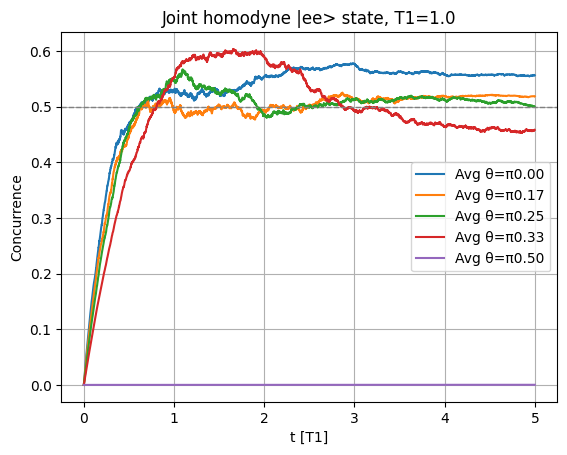

In [7]:
line_theta = []
line_theo = []

for i, theta in enumerate(my_theta):
    # plottiamo la curva per il theta i-esimo
    line_theta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom[i], label=f"Avg θ=π{(theta):.2f}")
    line_theta.append(line_theta_temp)

    #line_theor_temp, = plt.plot(times, theo_concurrence(times, GAMMA)*np.sin(np.pi*theta), color=line_theta_temp.get_color(), linestyle ='--', label=f"Theo θ={theta:.2f}")
    #line_theo.append(line_theor_temp)

#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Joint homodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_theta + line_theo)
plt.show()



# Inefficient joint homodyne detection
## $\sqrt{\gamma} \rightarrow \sqrt{\gamma \cdot \eta} $ and $\theta=\pi/2$

In [56]:
#my_theta = [0, 1/6, 1/4, 1/3, 1/2] # angles for the homodyne detection in unit of pi
my_eta = [1, 0.6] #etas for the homodyne detection

ntraj = 100

mean_conc_ee_solutions_jhom_ineff = []

psi0 = ee + gg + eg + ge
psi0 = psi0.unit()  # normalize the state

for eta in my_eta:       
        my_c_ops = [
        np.sqrt(GAMMA * (1-eta) / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(GAMMA * (1-eta) / 2) * (sigma_z_1 - sigma_z_2)*np.exp(1j * np.pi/2)
    ]
        
        my_sc_ops = [ 
        np.sqrt(GAMMA*eta / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(GAMMA*eta / 2) * (sigma_z_1 - sigma_z_2) * np.exp(1j * np.pi/2)
    ]
        
        jhom_ineff = smesolve(
            H_free, psi0.proj(), times,
            c_ops = my_c_ops,
            sc_ops = my_sc_ops, 
            ntraj=ntraj,
            e_ops=[concurrence_for_solver_mixed],
            options={"map": "parallel"},
        )

        mean_conc = jhom_ineff.expect[0]

        mean_conc_ee_solutions_jhom_ineff.append(mean_conc)

10.0%. Run time:   1.01s. Est. time left: 00:00:00:09
20.0%. Run time:   1.58s. Est. time left: 00:00:00:06
30.0%. Run time:   2.14s. Est. time left: 00:00:00:04
40.0%. Run time:   2.67s. Est. time left: 00:00:00:04
50.0%. Run time:   3.43s. Est. time left: 00:00:00:03
60.0%. Run time:   3.95s. Est. time left: 00:00:00:02
70.0%. Run time:   4.48s. Est. time left: 00:00:00:01
80.0%. Run time:   5.00s. Est. time left: 00:00:00:01
90.0%. Run time:   5.70s. Est. time left: 00:00:00:00
100.0%. Run time:   6.47s. Est. time left: 00:00:00:00
Total run time:   6.47s
10.0%. Run time:   0.92s. Est. time left: 00:00:00:08
20.0%. Run time:   1.41s. Est. time left: 00:00:00:05
30.0%. Run time:   1.95s. Est. time left: 00:00:00:04
40.0%. Run time:   2.60s. Est. time left: 00:00:00:03
50.0%. Run time:   3.29s. Est. time left: 00:00:00:03
60.0%. Run time:   3.83s. Est. time left: 00:00:00:02
70.0%. Run time:   4.35s. Est. time left: 00:00:00:01
80.0%. Run time:   5.33s. Est. time left: 00:00:00:01
90.

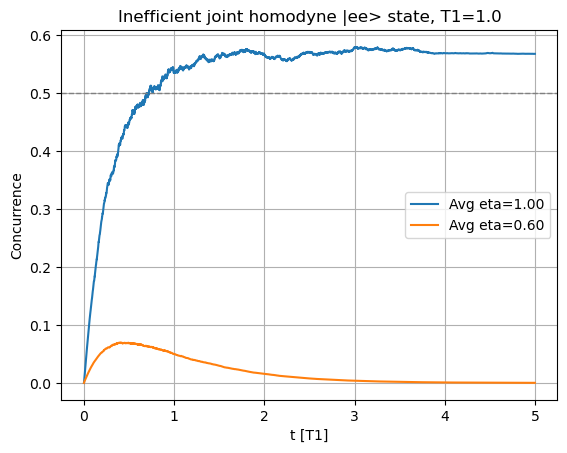

In [57]:
line_eta = []
line_theo_eta = []

for i, eta in enumerate(my_eta):
    # plottiamo la curva per il theta i-esimo
    line_eta_temp, = plt.plot(times, mean_conc_ee_solutions_jhom_ineff[i], label=f"Avg eta={(eta):.2f}")
    line_eta.append(line_eta_temp)


#line2, = plt.plot(times, conc_ee_solutions_jhom[11], label="Trajectory #10")
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='y = 0.5')
#plt.axhline(y=1, color='red', linestyle='-', linewidth=1.5, label='y = 1')

plt.xlabel("t [T1]")
plt.ylabel("Concurrence")
plt.title(f"Inefficient joint homodyne |ee> state, T1={T_1}")
plt.grid(True)
plt.legend(handles = line_eta + line_theo_eta)
plt.show()